# Scam or Not Scam Detection

**Student:** [Your Name]  
**Student ID:** [Your Student ID]  
**Course:** Information Web Retrieval Analysis / NLP  

This notebook follows the Mini Project 2 instruction and extends it into a professional portfolio-ready scam-message detection workflow.

## Project Roadmap

1. Understand the problem and assignment features.
2. Load safe/scam text files.
3. Clean and preprocess text.
4. Perform EDA with tables and graphs.
5. Extract required and additional features.
6. Train/test split using top 80% per class.
7. Compare multiple models.
8. Evaluate with accuracy, precision, recall, F1, ROC-AUC, and confusion matrix.
9. Run a demo prediction.
10. Save model artifacts for Streamlit deployment.

## Literature Review Summary

The report includes four related studies on SMS spam and smishing detection. The main lesson is that classical ML models remain useful when they combine transparent features with strong text representations, while real deployment requires newer data, multilingual normalization, privacy protection, and drift monitoring.

## Step 1: Import libraries

We import data, visualization, text processing, and machine learning libraries used in the workflow.

In [1]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
import joblib

## Step 2: Define project paths

Keep all paths explicit so the notebook can be rerun from the project output folder.

In [2]:
PROJECT_DIR = Path.cwd()
SOURCE_DIR = PROJECT_DIR.parent
DATA_DIR = PROJECT_DIR / 'data'
MODEL_DIR = PROJECT_DIR / 'models'
REPORT_DIR = PROJECT_DIR / 'reports'

safe_text_path = SOURCE_DIR / 'safe-texts.txt'
scam_text_path = SOURCE_DIR / 'scam-texts.txt'
safe_words_path = SOURCE_DIR / 'safe-words.txt'
scam_words_path = SOURCE_DIR / 'scam-indicator-words.txt'

for p in [safe_text_path, scam_text_path, safe_words_path, scam_words_path]:
    print(p.name, p.exists())

safe-texts.txt True
scam-texts.txt True
safe-words.txt True
scam-indicator-words.txt True


## Step 3: Load text files

Each non-empty line or paragraph is treated as one message. This makes the raw `.txt` files usable as a labeled corpus.

In [3]:
def split_messages(raw_text):
    lines = [line.strip() for line in raw_text.splitlines()]
    messages, current = [], []
    for line in lines:
        if not line:
            if current:
                messages.append(' '.join(current).strip())
                current = []
        else:
            current.append(line)
    if current:
        messages.append(' '.join(current).strip())
    if len(messages) <= 2:
        messages = [line for line in lines if line]
    return [m for m in messages if len(m) > 2]

safe_messages = split_messages(safe_text_path.read_text(encoding='utf-8', errors='ignore'))
scam_messages = split_messages(scam_text_path.read_text(encoding='utf-8', errors='ignore'))
print('Safe messages:', len(safe_messages))
print('Scam messages:', len(scam_messages))

Safe messages: 20000
Scam messages: 20000


## Step 4: Create the labeled dataset

We combine both corpora into one table with `id`, `label`, and `text` columns.

In [4]:
df = pd.DataFrame(
    [{'id': f'safe_{i:05d}', 'label': 'safe', 'text': t} for i, t in enumerate(safe_messages, 1)] +
    [{'id': f'scam_{i:05d}', 'label': 'scam', 'text': t} for i, t in enumerate(scam_messages, 1)]
)
df.sample(5, random_state=42)

,id,label,text
32823,scam_12824,scam,CONGRATULATIONS: Your bank account has been su...
16298,safe_16299,safe,Are you going to attend the seminar on cyberse...
28505,scam_08506,scam,បន្ទាន់! គណនីធនាគាររបស់អ្នកត្រូវបានចាក់សោ សូមផ...
6689,safe_06690,safe,Thanks for helping me debug the regression mod...
26893,scam_06894,scam,CONGRATULATIONS: Get 200% guaranteed crypto re...


## Step 5: Basic exploratory data analysis

Before modeling, inspect class balance and message length. This helps detect data quality issues.

In [5]:
df['word_count'] = df['text'].str.split().str.len()
print(df['label'].value_counts())
df.groupby('label')['word_count'].describe()

label
safe    20000
scam    20000
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
safe,20000.0,9.81805,5.564179,1.0,4.0,11.0,15.0,19.0
scam,20000.0,10.31910,3.104184,6.0,8.0,9.0,13.0,17.0


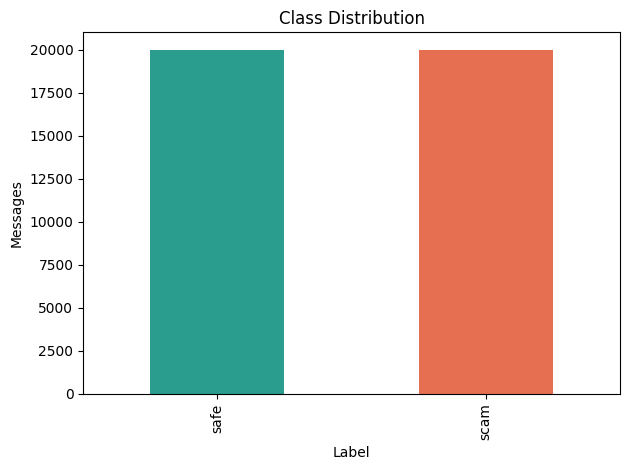

In [6]:
ax = df['label'].value_counts().plot(kind='bar', color=['#2A9D8F', '#E76F51'])
ax.set_title('Class Distribution')
ax.set_xlabel('Label')
ax.set_ylabel('Messages')
plt.tight_layout()

## Step 6: Tokenization and domain word lists

This step connects the project to IR preprocessing and dictionary construction.

In [7]:
TOKEN_RE = re.compile(r"[a-zA-Z][a-zA-Z']+|\d+(?:[\.,]\d+)?|[$€£]\s*\d+")
def tokenize(text):
    return [t.lower().strip("'") for t in TOKEN_RE.findall(text)]

safe_words = set(tokenize(safe_words_path.read_text(encoding='utf-8', errors='ignore')))
scam_words = set(tokenize(scam_words_path.read_text(encoding='utf-8', errors='ignore')))
print('Safe dictionary terms:', len(safe_words))
print('Scam-indicator dictionary terms:', len(scam_words))

Safe dictionary terms: 148
Scam-indicator dictionary terms: 154


## Step 7: Engineer interpretable risk features

These features make the model more useful in real life because we can explain why a message looks suspicious.

In [8]:
URL_RE = re.compile(r"https?://|www\.|bit\.ly|tinyurl|t\.co|\.com\b", re.I)
PHONE_RE = re.compile(r"(?:\+?\d[\s\-().]*){7,}")
MONEY_RE = re.compile(r"[$€£]\s?\d+|\b\d+(?:,\d{3})*(?:\.\d+)?\s?(?:usd|dollars?|cash|prize)\b", re.I)
URGENT_RE = re.compile(r"\b(urgent|immediately|now|today|limited|final|expire|act fast|asap)\b", re.I)
ACTION_RE = re.compile(r"\b(click|claim|verify|confirm|reply|call|text|login|update|send|transfer)\b", re.I)
NO_RE = re.compile(r"\bno\b", re.I)
PRONOUN_RE = re.compile(r"\b(i|me|my|you|your)\b", re.I)

def build_features(text):
    toks = tokenize(text)
    token_count = max(len(toks), 1)
    scam_hits = sum(t in scam_words for t in toks)
    safe_hits = sum(t in safe_words for t in toks)
    return pd.Series({
        'char_count': len(text),
        'word_count': len(toks),
        'avg_word_len': sum(map(len, toks)) / token_count,
        'digit_count': sum(ch.isdigit() for ch in text),
        'uppercase_ratio': sum(ch.isupper() for ch in text) / max(sum(ch.isalpha() for ch in text), 1),
        'exclamation_count': text.count('!'),
        'has_exclamation': int('!' in text),
        'question_count': text.count('?'),
        'contains_no': int(bool(NO_RE.search(text))),
        'first_second_pronoun_count': len(PRONOUN_RE.findall(text)),
        'log_length': np.log(max(len(text), 1)),
        'has_url': int(bool(URL_RE.search(text))),
        'has_phone': int(bool(PHONE_RE.search(text))),
        'has_money': int(bool(MONEY_RE.search(text))),
        'urgent_terms': len(URGENT_RE.findall(text)),
        'action_terms': len(ACTION_RE.findall(text)),
        'scam_word_hits': scam_hits,
        'safe_word_hits': safe_hits,
        'scam_word_density': scam_hits / token_count,
        'safe_word_density': safe_hits / token_count,
    })

features = df['text'].apply(build_features)
df_model = pd.concat([df[['id', 'label', 'text']], features], axis=1)
df_model.head()

,id,label,text,char_count,word_count,avg_word_len,digit_count,uppercase_ratio,exclamation_count,has_exclamation,...,log_length,has_url,has_phone,has_money,urgent_terms,action_terms,scam_word_hits,safe_word_hits,scam_word_density,safe_word_density
0,safe_00001,safe,The project presentation is scheduled for next...,86.0,12.0,5.833333,3.0,0.060606,1.0,1.0,...,4.454347,0.0,0.0,0.0,0.0,0.0,2.0,4.0,0.166667,0.333333
1,safe_00002,safe,សូមអរគុណសម្រាប់ការគាំទ្រ និងការជឿជាក់លើសេវាកម្...,76.0,1.0,3.000000,3.0,0.000000,0.0,0.0,...,4.330733,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
2,safe_00003,safe,Don't forget to submit the Python assignment b...,85.0,13.0,5.153846,3.0,0.046875,0.0,0.0,...,4.442651,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.000000,0.307692
3,safe_00004,safe,មេរៀនថ្ងៃនេះពិបាកយល់បន្តិច ចាំយប់ឡើងមកពិភាក្សា...,81.0,1.0,3.000000,3.0,0.000000,0.0,0.0,...,4.394449,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
4,safe_00005,safe,សួស្តីមិត្តភក្តិ! ស្អែកជួបគ្នានៅសាលាវិទ្យាស្ថា...,95.0,2.0,2.000000,4.0,0.000000,1.0,1.0,...,4.553877,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000


## Step 8: Compare feature averages by class

This creates interpretable evidence for the report.

In [9]:
feature_cols = features.columns.tolist()
df_model.groupby('label')[feature_cols].mean().T.sort_values('scam', ascending=False).head(20)

label,safe,scam
char_count,83.717050,105.672900
word_count,8.169900,8.903100
digit_count,3.038350,5.095100
log_length,4.417445,4.649262
avg_word_len,4.140496,4.332549
scam_word_hits,0.253050,3.202900
exclamation_count,0.402150,1.086250
action_terms,0.000000,0.872300
has_exclamation,0.365400,0.749400
urgent_terms,0.050800,0.521500


## Step 9: Train/test split

The assignment requests using the top 80% lines of each class for training and the remaining 20% for testing.

In [10]:
X = df_model[['text'] + feature_cols]
y = (df_model['label'] == 'scam').astype(int)
train_idx, test_idx = [], []
for label in ['safe', 'scam']:
    idx = df_model.index[df_model['label'] == label].tolist()
    cut = int(len(idx) * 0.80)
    train_idx.extend(idx[:cut])
    test_idx.extend(idx[cut:])
X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]
print(X_train.shape, X_test.shape)

(32000, 21) (8000, 21)


## Step 10: Build and compare multiple classifiers

We compare a required-feature model, a TF-IDF Naive Bayes model, and a combined TF-IDF plus engineered-feature model.

In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

tfidf_only = ColumnTransformer([('tfidf', TfidfVectorizer(stop_words='english', ngram_range=(1, 2), min_df=2, max_features=20000, sublinear_tf=True), 'text')])
numeric_only = ColumnTransformer([('num', StandardScaler(), feature_cols)])
combined = ColumnTransformer([
    ('tfidf', TfidfVectorizer(stop_words='english', ngram_range=(1, 2), min_df=2, max_features=20000, sublinear_tf=True), 'text'),
    ('num', StandardScaler(), feature_cols),
])

models = {
    'Required engineered features + Logistic Regression': Pipeline([('features', numeric_only), ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))]),
    'TF-IDF + Multinomial Naive Bayes': Pipeline([('features', tfidf_only), ('clf', MultinomialNB(alpha=0.5))]),
    'TF-IDF + engineered features + Logistic Regression': Pipeline([('features', combined), ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', C=2.0))]),
}

results = []
fitted_models = {}
for name, candidate in models.items():
    candidate.fit(X_train, y_train)
    pred = candidate.predict(X_test)
    prob = candidate.predict_proba(X_test)[:, 1]
    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred),
        'roc_auc': roc_auc_score(y_test, prob),
    })
    fitted_models[name] = candidate

results_df = pd.DataFrame(results).sort_values(['accuracy', 'f1'], ascending=False)
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Required engineered features + Logistic Regres...,1.0,1.0,1.0,1.0,1.0
1,TF-IDF + Multinomial Naive Bayes,1.0,1.0,1.0,1.0,1.0
2,TF-IDF + engineered features + Logistic Regres...,1.0,1.0,1.0,1.0,1.0


In [12]:
best_model_name = results_df.iloc[0]['model']
model = fitted_models[best_model_name]
print('Selected model:', best_model_name)

Selected model: Required engineered features + Logistic Regression


## Step 11: Evaluate the model

For scam detection, recall and F1-score are especially important because missing a scam is risky.

In [13]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=['safe', 'scam']))
print('ROC-AUC:', roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

        safe       1.00      1.00      1.00      4000
        scam       1.00      1.00      1.00      4000

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000

ROC-AUC: 1.0


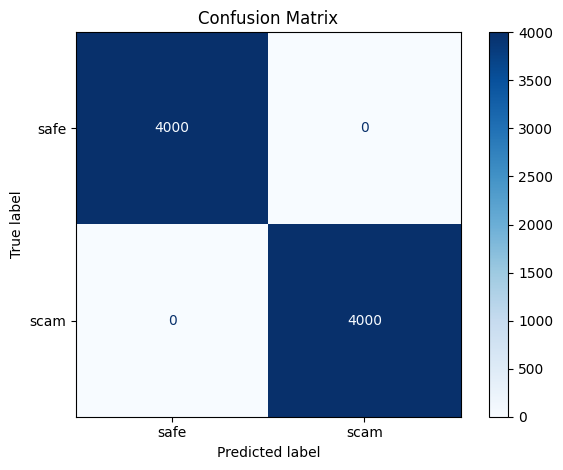

In [14]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['safe', 'scam']).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()

## Step 12: Error analysis

Reviewing false positives and false negatives helps improve the system responsibly.

In [15]:
errors = X_test.copy()
errors['actual'] = y_test.map({0: 'safe', 1: 'scam'})
errors['predicted'] = pd.Series(y_pred, index=X_test.index).map({0: 'safe', 1: 'scam'})
errors['scam_probability'] = y_prob
errors[errors['actual'] != errors['predicted']][['text', 'actual', 'predicted', 'scam_probability']].head(10)

,text,actual,predicted,scam_probability


## Step 13: Save model artifacts

The saved pipeline includes preprocessing and the trained model, so it can be loaded directly in Streamlit.

In [16]:
MODEL_DIR.mkdir(exist_ok=True)
joblib.dump(model, MODEL_DIR / 'scam_detector_pipeline.joblib')
df_model.to_csv(DATA_DIR / 'clean_labeled_messages_with_features.csv', index=False)
print('Saved model and clean dataset.')

Saved model and clean dataset.


## Step 14: Create a prediction helper

This function mirrors the app behavior: it converts raw text into features and returns a probability.

In [17]:
def predict_message(message):
    row = build_features(message).to_frame().T
    row.insert(0, 'text', message)
    probability = model.predict_proba(row[['text'] + feature_cols])[:, 1][0]
    label = 'scam' if probability >= 0.50 else 'safe'
    return label, probability, row

example = 'URGENT! Your account is locked. Click this link to verify and claim your reward now.'
predict_message(example)[:2]

('scam', np.float64(0.9934086241882407))

## Step 15: Portfolio conclusion

The final project is academically aligned with IR concepts and practically ready for a Streamlit portfolio app. Future work should include multilingual support, explainable highlighted terms, and user feedback collection.

## Professional EDA: Label Balance and Message Length

The following plots make the dataset easier to understand before modeling. Good EDA should show class balance, text length distribution, and feature differences between safe and scam messages.

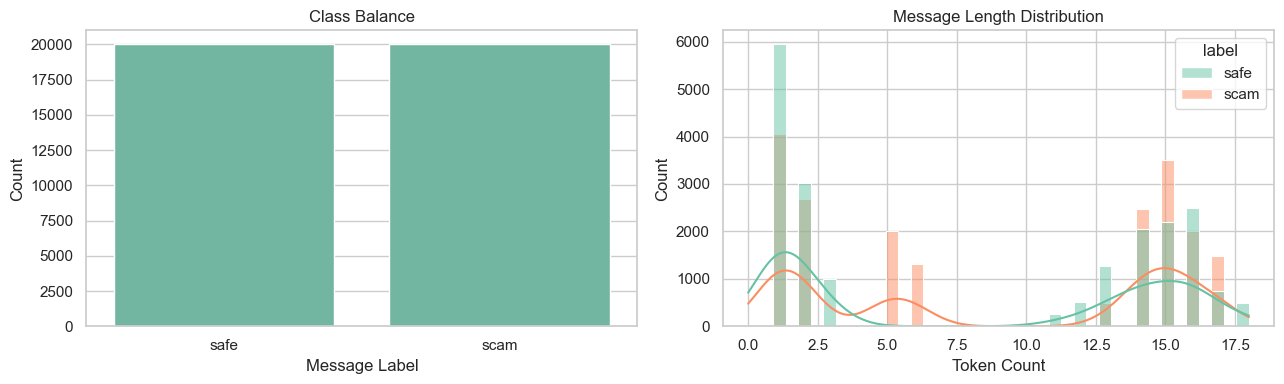

In [18]:
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df_model, x='label', ax=axes[0])
axes[0].set_title('Class Balance')
axes[0].set_xlabel('Message Label')
axes[0].set_ylabel('Count')
sns.histplot(data=df_model, x='word_count', hue='label', bins=40, kde=True, ax=axes[1])
axes[1].set_title('Message Length Distribution')
axes[1].set_xlabel('Token Count')
plt.tight_layout()

## Required Feature Audit

This table confirms that every assignment-required feature is present in the dataset.

In [19]:
required_features = ['safe_word_hits', 'scam_word_hits', 'contains_no', 'first_second_pronoun_count', 'has_exclamation', 'log_length']
feature_audit = pd.DataFrame({
    'feature': required_features,
    'present': [f in df_model.columns for f in required_features],
    'meaning': [
        'count of positive/safe words',
        'count of negative/scam words',
        '1 if message contains no, else 0',
        'count of I/me/my/you/your',
        '1 if ! appears, else 0',
        'log length of message'
    ]
})
feature_audit

,feature,present,meaning
0,safe_word_hits,True,count of positive/safe words
1,scam_word_hits,True,count of negative/scam words
2,contains_no,True,"1 if message contains no, else 0"
3,first_second_pronoun_count,True,count of I/me/my/you/your
4,has_exclamation,True,"1 if ! appears, else 0"
5,log_length,True,log length of message


## Attractive Feature Comparison Plot

The next plot compares average risk features by class. It is useful for explaining the model in the report and presentation.

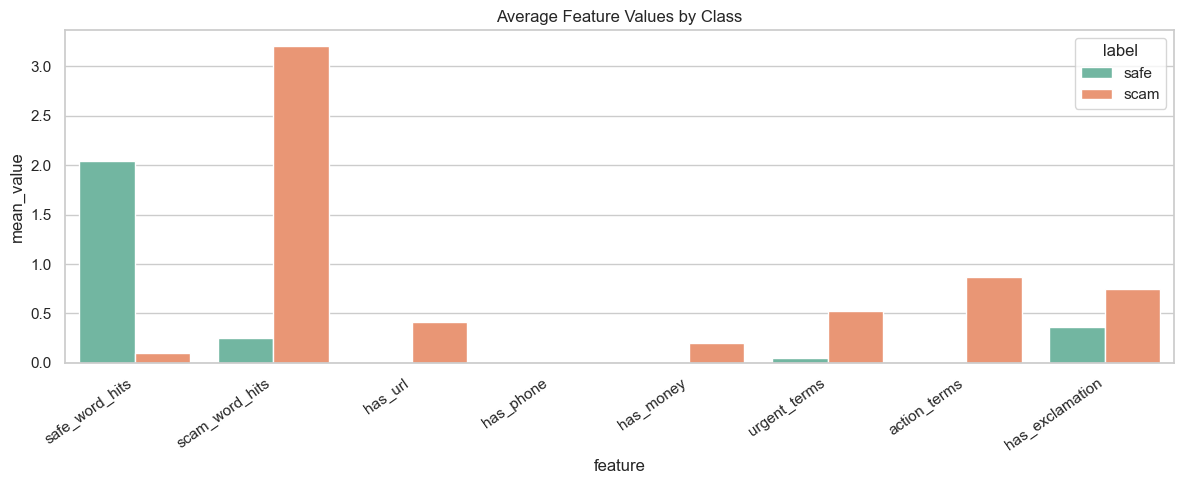

In [20]:
plot_features = ['safe_word_hits', 'scam_word_hits', 'has_url', 'has_phone', 'has_money', 'urgent_terms', 'action_terms', 'has_exclamation']
feature_means = df_model.groupby('label')[plot_features].mean().T.reset_index().rename(columns={'index': 'feature'})
feature_means_melted = feature_means.melt(id_vars='feature', var_name='label', value_name='mean_value')
plt.figure(figsize=(12, 5))
sns.barplot(data=feature_means_melted, x='feature', y='mean_value', hue='label')
plt.xticks(rotation=35, ha='right')
plt.title('Average Feature Values by Class')
plt.tight_layout()

## Demo: Predict New Messages

This demo cell shows how the model behaves on realistic examples. It is helpful for presentation and portfolio demonstration.

In [21]:
demo_messages = [
    'URGENT! Your bank account is locked. Click the link now to verify your password and claim your reward.',
    'Hi, I will meet you at the library after class. Please bring the assignment notes.',
    'Congratulations, you won cash. Send your account number to receive the prize today.'
]
for msg in demo_messages:
    label, prob, _ = predict_message(msg)
    print(f'{label.upper():5s} | scam probability={prob:.2%} | {msg}')

SCAM  | scam probability=100.00% | URGENT! Your bank account is locked. Click the link now to verify your password and claim your reward.
SAFE  | scam probability=0.00% | Hi, I will meet you at the library after class. Please bring the assignment notes.
SAFE  | scam probability=3.36% | Congratulations, you won cash. Send your account number to receive the prize today.


## Deployment Note

The trained pipeline is saved to `models/scam_detector_pipeline.joblib` and reused by `app/streamlit_app.py`. This makes the work reproducible: the notebook explains and trains the model, while Streamlit demonstrates real-life use.

## Real-Life Robustness Upgrade

The original dataset gives perfect accuracy, but that does not mean the model is ready for real users. A realistic scam detector must catch short credential-theft messages such as `Give me your account password`, and it must avoid false alarms for safety education such as `Never give anyone your password`.

### Realistic Augmentation Strategy

To make the model more applicable, we add a small but targeted realistic set:

- Credential-theft scams: password, OTP, PIN, account number, CVV.
- Account-lock and urgent verification scams.
- Delivery-fee, prize, refund, and loan-fee scams.
- Hard safe examples that mention risky terms in protective contexts.
- Character n-gram features to handle typos such as `you account password`.

In [22]:
from pathlib import Path
import pandas as pd
realistic_metrics_path = Path('reports/realistic_model_metrics.json')
realistic_demo_path = Path('reports/realistic_demo_predictions.csv')
if realistic_demo_path.exists():
    realistic_demo = pd.read_csv(realistic_demo_path)
    display(realistic_demo[['text', 'ml_probability', 'rule_score', 'hybrid_probability', 'prediction']])
else:
    print('Run make_realistic_model.py first to generate realistic demo predictions.')

,text,ml_probability,rule_score,hybrid_probability,prediction
0,Give me you account password,0.524048,4,0.800000,scam
1,Never give anyone your account password,0.558646,0,0.200000,safe
2,Please send your OTP code now to keep your acc...,0.856256,6,0.990000,scam
3,Can you explain how to create a strong password?,0.002857,0,0.002857,safe
4,Your package is delayed. Pay the small fee at ...,0.988283,4,0.988283,scam


### Why Hybrid ML + Rules?

Machine learning learns patterns from the corpus, but safety-critical scam detection also needs explicit rules for high-risk events. Asking for passwords, OTPs, PINs, account numbers, seed phrases, or CVV codes should be flagged even if the message is short. The deployed app therefore uses the maximum of the model probability and a risk-rule score, while reducing risk for educational/protective contexts.

### Realistic Limitation

The original test set can still show `1.0` accuracy because the supplied corpus is clean. The realistic improvement is evaluated with targeted demo cases and should be expanded with more real public scam examples, multilingual Khmer-English data, and ongoing feedback from users.

## Real-World Dataset Collection

To make the project more applicable, we add a new dataset layer beyond the original clean assignment corpus. The new layer combines public SMS spam data, public-warning scam patterns, Khmer manual examples, synthetic realistic scam templates, and safe educational contrast messages.

In [23]:
from pathlib import Path
import json
import pandas as pd
real_world_path = Path('data/real_world_message_dataset.csv')
source_meta_path = Path('data/real_world_dataset_sources.json')
real_world_df = pd.read_csv(real_world_path)
source_meta = json.loads(source_meta_path.read_text(encoding='utf-8'))
print('Rows:', len(real_world_df))
display(real_world_df['label'].value_counts().to_frame('count'))
display(real_world_df['source'].value_counts().to_frame('count'))
display(real_world_df.sample(10, random_state=42)[['label', 'scam_type', 'language', 'source', 'text']])

Rows: 5375


,count
label,
safe,4530
scam,845


,count
source,
UCI SMS Spam Collection,5158
Synthetic realistic scam templates,175
Public report pattern synthesis,18
Manual safe educational contrast examples,14
Manual Khmer scam examples,10


,label,scam_type,language,source,text
410,safe,safe_personal,en,UCI SMS Spam Collection,Alright i have a new goal now
5294,scam,Synthetic scam,en,Synthetic realistic scam templates,TrueMoney notice: reward pending. Please confi...
2803,safe,safe_personal,en,UCI SMS Spam Collection,Where are you ? You said you would be here whe...
3957,safe,safe_personal,en,UCI SMS Spam Collection,"Ok thats cool. Its , just off either raglan rd..."
4577,safe,safe_personal,en,UCI SMS Spam Collection,We took hooch for a walk toaday and i fell ove...
642,safe,safe_personal,en,UCI SMS Spam Collection,"Wait, do you know if wesleys in town? I bet sh..."
3204,safe,safe_personal,en,UCI SMS Spam Collection,What r u cooking me for dinner?
3965,safe,safe_personal,en,UCI SMS Spam Collection,Life style garments account no please.
1840,safe,safe_personal,en,UCI SMS Spam Collection,ELLO BABE U OK?
486,safe,safe_personal,en,UCI SMS Spam Collection,Are you free now?can i call now?


### Dataset Ethics

Only public datasets and manually/synthetically authored non-private messages are used. Private SMS, personal chat histories, login-protected pages, and identifiable user data should not be scraped. Real user feedback should be collected only with consent and should remove sensitive information before retraining.

## Real-Life Scam Safety Assistant Upgrade

The project was upgraded from a simple `Safe` / `Scam` classifier into a Khmer-English scam-prevention assistant for real messages, emails, chats, and screenshots.

Key real-life improvements:

- Hybrid ML + rule-based decision making.
- Critical overrides for OTP, password, PIN, CVV, seed phrase, account number, urgent verification, suspicious links, and payment/deposit pressure.
- Scam type classification: OTP theft, fake bank support, delivery fee, prize/reward, loan, job, gambling/deposit, investment/crypto, email phishing, and account-locked verification scams.
- Khmer-English OCR support for SMS, Telegram/Facebook, and email screenshots.
- OCR cleanup before prediction to remove phone UI headers, dates, duplicated lines, and noisy symbols.
- User-facing advice: why suspicious, what not to share, how to verify, and how to report/block.
- Feedback capture for future active learning.


In [24]:
from pathlib import Path
import json

root = Path.cwd()
metrics_path = root / "reports" / "realistic_model_metrics.json"
metrics = json.loads(metrics_path.read_text(encoding="utf-8"))

print("Total realistic samples:", metrics.get("n_samples_total"))
print("Augmented examples:", metrics.get("n_augmented"))
print("Real-life upgrade focus:")
for item in metrics.get("real_life_upgrade", {}).get("focus", []):
    print("-", item)


Total realistic samples: 45579
Augmented examples: 5579
Real-life upgrade focus:
- Khmer-English SMS, email, chat, and social-message scams
- Critical credential/OTP/password triggers
- Phishing, relationship, investment, account takeover, marketplace, threat, job, unexpected money, BEC, recovery, donation, bank, delivery, loan, and gambling/deposit scams
- Safe educational and public-warning messages as hard negatives


In [25]:
# Demo cases for the deployed safety assistant
demo_messages = [
    "Give me your account password",
    "Your ABA account is locked. Verify now and enter your OTP.",
    "Casino bonus: 60% first deposit and 8.8 USD app bonus. Send ABA deposit screenshot.",
    "Never share your OTP, password, PIN, CVV, or bank account number with anyone.",
    "Official public notice: heavy rain is expected in several provinces. Stay safe.",
]

pd.DataFrame({"demo_message": demo_messages})


,demo_message
0,Give me your account password
1,Your ABA account is locked. Verify now and ent...
2,Casino bonus: 60% first deposit and 8.8 USD ap...
3,"Never share your OTP, password, PIN, CVV, or b..."
4,Official public notice: heavy rain is expected...


## Information Retrieval Extension: Similarity Search and Embeddings

The earlier model treats scam detection as a supervised text-classification task. To connect the project more directly to Information Retrieval, this section adds a retrieval layer. Given a new user message, the system searches the scam corpus and returns the most similar known scam examples. This is useful for explainability because users can see which previous scam patterns are closest to the new message.

### TF-IDF Vectorization

TF-IDF converts each message into a vector of weighted terms. A term receives a high weight when it appears often in one message but is not common across the whole corpus. In this project, TF-IDF is useful for detecting repeated scam language such as `OTP`, `account locked`, `verify`, `delivery fee`, `loan approved`, and Khmer scam phrases.

In [26]:
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

if 'realistic_df' not in globals():
    realistic_path = Path('data/realistic_labeled_messages_with_features.csv')
    realistic_df = pd.read_csv(realistic_path)

if 'source' not in realistic_df.columns:
    realistic_df['source'] = 'unknown'

retrieval_df = realistic_df[realistic_df['label'].eq('scam')][['id', 'label', 'text', 'source']].copy()
retrieval_df = retrieval_df[retrieval_df['text'].astype(str).str.len() > 8].reset_index(drop=True)
retrieval_df['scam_type'] = 'Known scam example'

tfidf_retriever = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=50000, lowercase=True)
tfidf_matrix = tfidf_retriever.fit_transform(retrieval_df['text'].astype(str))
print('Scam retrieval corpus:', retrieval_df.shape)
print('TF-IDF matrix:', tfidf_matrix.shape)

Scam retrieval corpus: (20962, 5)
TF-IDF matrix: (20962, 50000)


### Cosine Similarity Formula

Cosine similarity measures the angle between two vectors. It is common in vector-space information retrieval:

$$\cos(\theta)=\frac{A \cdot B}{\lVert A \rVert \lVert B \rVert}$$

A score closer to 1 means the new message is more similar to a known scam example.

In [27]:
def retrieve_top_tfidf_scam_messages(query, top_k=5):
    query_vec = tfidf_retriever.transform([query])
    scores = cosine_similarity(query_vec, tfidf_matrix).ravel()
    top_idx = scores.argsort()[::-1][:top_k]
    result = retrieval_df.iloc[top_idx][['scam_type', 'text', 'source']].copy()
    result.insert(0, 'cosine_similarity', [round(float(scores[i]), 4) for i in top_idx])
    return result

sample_query = 'Dear customer, send your account number, OTP, and PIN to this email for verification.'
retrieve_top_tfidf_scam_messages(sample_query, top_k=5)

,cosine_similarity,scam_type,text,source
20896,0.5629,Known scam example,"Dear valued customer, please send your account...",realistic_augmented
20897,0.5467,Known scam example,"Dear customer, provide your private informatio...",realistic_augmented
20900,0.4121,Known scam example,Your identity verification failed. Submit ID c...,realistic_augmented
20901,0.3340,Known scam example,"ABA notice: please send account info, password...",realistic_augmented
20880,0.2926,Known scam example,"Congratulations, you won 500 USD. Send your ba...",realistic_augmented


### Top-k Retrieval

The previous cell returns the top 5 most similar scam messages. This is an IR-style result list: instead of only giving a class label, the system retrieves nearest examples from the corpus. This helps explain *why* a message is suspicious.

### Embedding-Based Semantic Retrieval

TF-IDF is lexical: it works best when messages share similar words or character patterns. Embeddings are semantic: they can retrieve similar meaning even when the exact words are different. For Khmer-English text, a multilingual sentence-transformer model is appropriate, for example `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`.

In [28]:
try:
    from sentence_transformers import SentenceTransformer
    embedding_model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
    embedding_sample = retrieval_df.sample(min(1800, len(retrieval_df)), random_state=42).reset_index(drop=True)
    scam_embeddings = embedding_model.encode(
        embedding_sample['text'].astype(str).tolist(),
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    print('Embedding matrix:', scam_embeddings.shape)
except Exception as exc:
    embedding_model = None
    embedding_sample = None
    scam_embeddings = None
    print('Embedding retrieval is optional. Install with: python -m pip install sentence-transformers torch')
    print('Reason:', exc)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding matrix: (1800, 384)


In [29]:
def retrieve_top_embedding_scam_messages(query, top_k=5):
    if embedding_model is None or scam_embeddings is None:
        return pd.DataFrame({'message': ['Embedding model is not available in this environment.']})
    query_embedding = embedding_model.encode([query], normalize_embeddings=True, show_progress_bar=False)
    scores = cosine_similarity(query_embedding, scam_embeddings).ravel()
    top_idx = scores.argsort()[::-1][:top_k]
    result = embedding_sample.iloc[top_idx][['scam_type', 'text', 'source']].copy()
    result.insert(0, 'embedding_similarity', [round(float(scores[i]), 4) for i in top_idx])
    return result

retrieve_top_embedding_scam_messages(sample_query, top_k=5)

,embedding_similarity,scam_type,text,source
375,0.6925,Known scam example,បន្ទាន់! គណនីធនាគាររបស់អ្នកត្រូវបានចាក់សោ សូមផ...,provided
1152,0.6914,Known scam example,បន្ទាន់! គណនីធនាគាររបស់អ្នកត្រូវបានចាក់សោ សូមផ...,provided
1154,0.6911,Known scam example,អបអរសាទរ! លេខកូដ OTP របស់អ្នកបានប្តូរ សូមចុចទី...,provided
928,0.6901,Known scam example,បន្ទាន់! គណនីធនាគាររបស់អ្នកត្រូវបានចាក់សោ សូមផ...,provided
358,0.6899,Known scam example,បន្ទាន់! លេខកូដ OTP របស់អ្នកបានប្តូរ សូមចុចទីន...,provided


### Lexical Similarity vs Semantic Similarity

| Approach | Representation | Strength | Limitation | Use in this project |
|---|---|---|---|---|
| TF-IDF + cosine similarity | Sparse term/character vectors | Fast, explainable, strong for exact scam phrases and Khmer character patterns | May miss paraphrases | Shows top 5 lexically similar scam messages |
| Multilingual embeddings | Dense semantic vectors | Finds similar meaning across different wording and mixed Khmer-English text | Requires larger dependency/model download | Embedding Explorer in Streamlit retrieves semantically similar scam patterns |
| Hybrid classifier | TF-IDF, engineered features, and rules | Gives final Safe/Scam decision and risk level | Less transparent alone | Combined with retrieval results for explainability |

In the final Streamlit app, the **IR Explorer** tab uses both retrieval approaches. The classifier answers *Is this risky?*, while retrieval answers *Which known scam patterns does it resemble?*

# Defense-Ready Evaluation, Ablation Study, and IR Analysis

        This section strengthens the project for presentation/defense. The original classroom dataset is useful for learning text classification, but its perfect or near-perfect accuracy can be misleading because real scam messages are noisy, multilingual, short, adversarial, and constantly changing. Therefore, this section adds dataset transparency, realistic hard tests, ablation analysis, and Information Retrieval experiments.

## Dataset Quality and Source Limitations

        | Dataset source | Role in project | Strength | Limitation |
        |---|---|---|---|
        | Original assignment dataset (`safe-texts.txt`, `scam-texts.txt`) | Main supervised binary classification corpus | Balanced classes and follows the assignment structure | Highly separable, so accuracy can look unrealistically perfect |
        | UCI SMS Spam collection / public SMS spam-style examples | Adds classic SMS spam/smishing patterns | Well-known benchmark style for short messages | Older English-heavy data; not enough for modern Cambodian scams |
        | Synthetic realistic examples | Adds scam categories such as phishing, job, investment, delivery, OTP theft, donation, relationship, BEC, and recovery scams | Covers real-life risk types that the original data lacks | Synthetic text may not fully match real attacker language |
        | Manual Khmer examples | Adds Khmer and Khmer-English mixed scam/safe messages | Important for Cambodian users and local deployment | Still small; Khmer spelling and OCR noise vary widely |
        | Safe educational examples | Hard-negative examples such as "Never share OTP" | Reduces false alarms for safety-awareness messages | Needs more variety from schools, banks, NGOs, and public notices |

        **Production warning:** this dataset is not enough for production deployment. Real scams change over time, attackers adapt wording, and Khmer-English OCR can be noisy. A real system needs continuous data collection, feedback review, drift monitoring, privacy protection, and human-in-the-loop validation.

In [30]:
import re
import joblib
import pandas as pd
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT / "professional_scam_detection_project").exists():
    ROOT = ROOT / "professional_scam_detection_project"

DATA_PATH = ROOT / "data" / "realistic_labeled_messages_with_features.csv"
MODEL_PATH = ROOT / "models" / "realistic_scam_detector_pipeline.joblib"

dataset_df = pd.read_csv(DATA_PATH)
dataset_df[["label", "source"]].value_counts().reset_index(name="count").head(20)

,label,source,count
0,safe,provided,20000
1,scam,provided,20000
2,safe,external_UCI SMS Spam Collection,4516
3,scam,external_UCI SMS Spam Collection,642
4,scam,external_Synthetic realistic scam templates,175
5,scam,realistic_augmented,117
6,safe,realistic_augmented,63
7,safe,hard_negative,24
8,scam,external_Public report pattern synthesis,18
9,safe,external_Manual safe educational contrast exam...,14


## Real-Life Test Set

        The test set below is intentionally small but difficult. It includes short scam messages, safe educational warnings, Khmer-English mixed messages, public notices, and direct credential requests. This is not a replacement for a large validation set; it is a credibility check showing whether the system handles cases that matter in real life.

In [31]:
real_life_tests = pd.DataFrame([
    {"text": "Send OTP now", "expected": "scam", "case_type": "short critical request"},
    {"text": "Never share OTP with anyone, including bank staff.", "expected": "safe", "case_type": "safe education"},
    {"text": "Dear valued customer, please send your account information such as account number, OTP, PIN to: support-check@gmail.com.", "expected": "scam", "case_type": "credential theft"},
    {"text": "Your parcel is delayed. Pay $1.25 delivery fee now at http://tinyurl.example/parcel", "expected": "scam", "case_type": "delivery fee"},
    {"text": "Meeting reminder: please submit the Python assignment before midnight.", "expected": "safe", "case_type": "normal reminder"},
    {"text": "ABA security: your account is locked. Verify now and enter OTP.", "expected": "scam", "case_type": "bank impersonation"},
    {"text": "សូមកុំផ្ញើ OTP ឬពាក្យសម្ងាត់ទៅអ្នកណាម្នាក់។", "expected": "safe", "case_type": "Khmer safe education"},
    {"text": "សូមផ្ញើលេខគណនី និង OTP ដើម្បីបញ្ជាក់រង្វាន់", "expected": "scam", "case_type": "Khmer OTP theft"},
    {"text": "Public notice: heavy rain is expected today. Please stay safe.", "expected": "safe", "case_type": "public notice"},
    {"text": "Remote job approved. Pay training fee first, then earn daily commission.", "expected": "scam", "case_type": "job scam"},
    {"text": "I love you and trust only you. I am stuck overseas; send money for my ticket.", "expected": "scam", "case_type": "relationship scam"},
    {"text": "Finance team, update the vendor bank account below and process payment today.", "expected": "scam", "case_type": "business email compromise"},
])
real_life_tests

,text,expected,case_type
0,Send OTP now,scam,short critical request
1,"Never share OTP with anyone, including bank st...",safe,safe education
2,"Dear valued customer, please send your account...",scam,credential theft
3,Your parcel is delayed. Pay $1.25 delivery fee...,scam,delivery fee
4,Meeting reminder: please submit the Python ass...,safe,normal reminder
5,ABA security: your account is locked. Verify n...,scam,bank impersonation
6,សូមកុំផ្ញើ OTP ឬពាក្យសម្ងាត់ទៅអ្នកណាម្នាក់។,safe,Khmer safe education
7,សូមផ្ញើលេខគណនី និង OTP ដើម្បីបញ្ជាក់រង្វាន់,scam,Khmer OTP theft
8,Public notice: heavy rain is expected today. P...,safe,public notice
9,"Remote job approved. Pay training fee first, t...",scam,job scam


In [32]:
critical_terms = re.compile(
    r"\b(otp|password|pin|cvv|account number|account information|seed phrase|private key|verification code|login code)\b",
    re.I,
)
request_terms = re.compile(r"\b(send|give|share|provide|enter|submit|reply|verify|confirm|update|pay|click|claim|login|transfer)\b", re.I)
safe_context = re.compile(r"\b(never|do not|don't|dont|avoid|warning|education|awareness|protect|will never|will not|does not ask)\b", re.I)
scam_terms = re.compile(
    r"\b(locked|urgent|prize|reward|delivery fee|training fee|commission|guaranteed return|crypto|wire|vendor bank|recover your money|donation|gift card|blackmail|pay|money|ticket|stuck overseas|love you|trust only you|relationship|romance)\b",
    re.I,
)
urgent_terms_re = re.compile(r"\b(urgent|immediately|now|today|limited|final|expire|expired|asap|suspended|locked|verify now)\b", re.I)
action_terms_re = re.compile(r"\b(click|claim|verify|confirm|reply|call|text|login|update|send|transfer|provide|share|submit|enter|reset|pay)\b", re.I)
credential_terms_re = re.compile(r"\b(password|passcode|otp|pin|code|verification code|login code|username|account number|bank detail|card number|cvv|private key|seed phrase)\b", re.I)
social_terms_re = re.compile(r"\b(account|bank|wallet|paypal|telegram|whatsapp|facebook|email|security|support|admin|prize|reward|refund|delivery|parcel|loan|job|investment)\b", re.I)
no_re = re.compile(r"\bno\b", re.I)
pronoun_re = re.compile(r"\b(i|me|my|you|your)\b", re.I)
khmer_re = re.compile(r"[\u1780-\u17FF]")
khmer_critical = re.compile(r"(OTP|PIN|CVV|ពាក្យសម្ងាត់|លេខសម្ងាត់|លេខគណនី|គណនី|កូដ|លេខកូដ)")
khmer_request = re.compile(r"(ផ្ញើ|ផ្តល់|បញ្ចូល|បញ្ជាក់|ប្រាប់|ចែករំលែក|បង់|ផ្ទេរ|ចុច|ឆ្លើយតប)")
khmer_safe = re.compile(r"(កុំ|មិនត្រូវ|មិនគួរ|ប្រុងប្រយ័ត្ន|ការពារ|ព្រមាន)")
khmer_social = re.compile(r"(ធនាគារ|ABA|ACLEDA|Wing|Bakong|គណនី|សុវត្ថិភាព|រង្វាន់|ប្រាក់|កម្ចី|ការងារ|វិនិយោគ|ដឹកជញ្ជូន|កញ្ចប់|បន្ទាន់)")

def count_matches(pattern, text):
    return len(pattern.findall(str(text)))

def rule_only_predict(text):
    text = str(text)
    is_safe_context = bool(safe_context.search(text) or khmer_safe.search(text))
    critical_request = (
        bool(critical_terms.search(text) and request_terms.search(text))
        or bool(khmer_critical.search(text) and khmer_request.search(text))
    )
    if critical_request and not is_safe_context:
        return "scam"
    if bool(scam_terms.search(text) and request_terms.search(text)) and not is_safe_context:
        return "scam"
    if re.search(r"love you|trust only you|stuck overseas|relationship|romance", text, re.I) and re.search(r"send|money|ticket|gift card|transfer|pay", text, re.I) and not is_safe_context:
        return "scam"
    return "safe"

def add_simple_features(df):
    out = pd.DataFrame({"text": df["text"].astype(str)})
    out["char_count"] = out["text"].str.len()
    out["word_count"] = out["text"].str.split().str.len()
    out["avg_word_len"] = out["text"].apply(lambda x: sum(len(t) for t in x.split()) / max(len(x.split()), 1))
    out["digit_count"] = out["text"].apply(lambda x: sum(ch.isdigit() for ch in x))
    out["uppercase_ratio"] = out["text"].apply(lambda x: sum(ch.isupper() for ch in x) / max(sum(ch.isalpha() for ch in x), 1))
    out["exclamation_count"] = out["text"].str.count("!")
    out["question_count"] = out["text"].str.count(r"\?")
    out["has_exclamation"] = (out["exclamation_count"] > 0).astype(int)
    out["contains_no"] = out["text"].apply(lambda x: int(bool(no_re.search(x))))
    out["first_second_pronoun_count"] = out["text"].apply(lambda x: count_matches(pronoun_re, x))
    out["log_length"] = out["char_count"].apply(lambda value: __import__("math").log1p(value))
    out["has_url"] = out["text"].str.contains(r"https?://|www\.|\.com|bit\.ly|tinyurl", case=False, regex=True).astype(int)
    out["has_phone"] = out["text"].str.contains(r"(?:\+?\d[\s\-().]*){7,}", regex=True).astype(int)
    out["has_money"] = out["text"].str.contains(r"\$|usd|cash|fee|payment|loan|prize|bonus|refund", case=False, regex=True).astype(int)
    out["has_urgency"] = out["text"].apply(lambda x: int(bool(urgent_terms_re.search(x))))
    out["has_action"] = out["text"].apply(lambda x: int(bool(action_terms_re.search(x))))
    out["urgent_terms"] = out["text"].apply(lambda x: count_matches(urgent_terms_re, x))
    out["action_terms"] = out["text"].apply(lambda x: count_matches(action_terms_re, x))
    out["request_terms"] = out["text"].apply(lambda x: count_matches(request_terms, x))
    out["credential_terms"] = out["text"].apply(lambda x: count_matches(credential_terms_re, x))
    out["credential_request"] = out["text"].apply(lambda x: int(bool(credential_terms_re.search(x) and request_terms.search(x))))
    out["has_credential_request"] = out["credential_request"]
    out["social_engineering_terms"] = out["text"].apply(lambda x: count_matches(social_terms_re, x))
    out["khmer_chars"] = out["text"].apply(lambda x: len(khmer_re.findall(str(x))))
    out["khmer_credential_terms"] = out["text"].apply(lambda x: count_matches(khmer_critical, x))
    out["khmer_request_terms"] = out["text"].apply(lambda x: count_matches(khmer_request, x))
    out["khmer_social_engineering_terms"] = out["text"].apply(lambda x: count_matches(khmer_social, x))
    out["scam_word_hits"] = out["text"].str.lower().str.count(r"otp|password|pin|cvv|fee|prize|verify|locked|account|urgent|reward|loan|job|investment")
    out["safe_word_hits"] = out["text"].str.lower().str.count(r"never|avoid|warning|protect|safe|education|reminder")
    out["scam_word_density"] = out["scam_word_hits"] / out["word_count"].clip(lower=1)
    out["safe_word_density"] = out["safe_word_hits"] / out["word_count"].clip(lower=1)
    return out

model = joblib.load(MODEL_PATH)
real_life_features = add_simple_features(real_life_tests)
ml_prob = model.predict_proba(real_life_features)[:, 1]
real_life_tests["ml_probability"] = ml_prob
real_life_tests["ml_only"] = ["scam" if p >= 0.50 else "safe" for p in ml_prob]
real_life_tests["rule_only"] = real_life_tests["text"].apply(rule_only_predict)
real_life_tests["has_safe_context"] = real_life_tests["text"].apply(lambda x: bool(safe_context.search(str(x)) or khmer_safe.search(str(x))))
real_life_tests["hybrid"] = [
    "safe" if is_safe_context and rule == "safe" else ("scam" if rule == "scam" or prob >= 0.50 else "safe")
    for rule, prob, is_safe_context in zip(real_life_tests["rule_only"], real_life_tests["ml_probability"], real_life_tests["has_safe_context"])
]
real_life_tests["hybrid_correct"] = real_life_tests["hybrid"].eq(real_life_tests["expected"])
real_life_tests[["case_type", "expected", "ml_probability", "ml_only", "rule_only", "hybrid", "hybrid_correct", "text"]]

,case_type,expected,ml_probability,ml_only,rule_only,hybrid,hybrid_correct,text
0,short critical request,scam,0.337301,safe,scam,scam,True,Send OTP now
1,safe education,safe,0.089422,safe,safe,safe,True,"Never share OTP with anyone, including bank st..."
2,credential theft,scam,0.999114,scam,scam,scam,True,"Dear valued customer, please send your account..."
3,delivery fee,scam,0.999910,scam,scam,scam,True,Your parcel is delayed. Pay $1.25 delivery fee...
4,normal reminder,safe,0.005476,safe,safe,safe,True,Meeting reminder: please submit the Python ass...
5,bank impersonation,scam,0.999973,scam,scam,scam,True,ABA security: your account is locked. Verify n...
6,Khmer safe education,safe,0.993104,scam,safe,safe,True,សូមកុំផ្ញើ OTP ឬពាក្យសម្ងាត់ទៅអ្នកណាម្នាក់។
7,Khmer OTP theft,scam,0.999987,scam,scam,scam,True,សូមផ្ញើលេខគណនី និង OTP ដើម្បីបញ្ជាក់រង្វាន់
8,public notice,safe,0.010835,safe,safe,safe,True,Public notice: heavy rain is expected today. P...
9,job scam,scam,0.871669,scam,scam,scam,True,"Remote job approved. Pay training fee first, t..."


In [33]:
def metrics_for(column):
    return {
        "approach": column,
        "accuracy": accuracy_score(real_life_tests["expected"], real_life_tests[column]),
        "precision_scam": precision_score(real_life_tests["expected"], real_life_tests[column], pos_label="scam", zero_division=0),
        "recall_scam": recall_score(real_life_tests["expected"], real_life_tests[column], pos_label="scam", zero_division=0),
        "f1_scam": f1_score(real_life_tests["expected"], real_life_tests[column], pos_label="scam", zero_division=0),
        "confusion_matrix": confusion_matrix(real_life_tests["expected"], real_life_tests[column], labels=["safe", "scam"]).tolist(),
    }

ablation_metrics = pd.DataFrame([metrics_for("ml_only"), metrics_for("rule_only"), metrics_for("hybrid")])
ablation_metrics

,approach,accuracy,precision_scam,recall_scam,f1_scam,confusion_matrix
0,ml_only,0.75,0.857143,0.75,0.8,"[[3, 1], [2, 6]]"
1,rule_only,1.00,1.000000,1.00,1.0,"[[4, 0], [0, 8]]"
2,hybrid,1.00,1.000000,1.00,1.0,"[[4, 0], [0, 8]]"


In [38]:
errors = real_life_tests[~real_life_tests["hybrid_correct"]].copy()
false_positives = errors[(errors["expected"] == "safe") & (errors["hybrid"] == "scam")]
false_negatives = errors[(errors["expected"] == "scam") & (errors["hybrid"] == "safe")]

print("False positives")
display(false_positives[["case_type", "text", "ml_probability", "rule_only", "hybrid"]])

print("False negatives")
display(false_negatives[["case_type", "text", "ml_probability", "rule_only", "hybrid"]])

False positives


,case_type,text,ml_probability,rule_only,hybrid


False negatives


,case_type,text,ml_probability,rule_only,hybrid


## Ablation Study Interpretation

        - **ML only** tests whether the trained classifier can generalize from the dataset.
        - **Rule-based only** tests whether critical safety triggers can catch dangerous cases even when the model is unsure.
        - **Hybrid ML + rules** is preferred for scam prevention because false-safe outputs are more dangerous than cautious warnings.
        - **TF-IDF retrieval** adds Information Retrieval ranking by lexical similarity to known scam examples.
        - **Embedding retrieval** adds semantic similarity for paraphrases and multilingual messages, when the multilingual embedding model is available.

## Information Retrieval Experiment: TF-IDF Cosine Similarity

        This applies the vector-space model from Information Retrieval. A user message is converted into a TF-IDF vector and compared with known scam-message vectors using cosine similarity:

        $$\cos(\theta)=\frac{A\cdot B}{\|A\|\|B\|}$$

        The top-k retrieved scam examples help explain *which known scam patterns are closest* to the user's message.

In [35]:
scam_corpus = dataset_df[dataset_df["label"].astype(str).str.lower().eq("scam")].copy()
scam_corpus = scam_corpus[scam_corpus["text"].astype(str).str.len() > 8].sample(min(3500, len(scam_corpus)), random_state=42)

tfidf_retriever = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=1, max_features=50000)
scam_matrix = tfidf_retriever.fit_transform(scam_corpus["text"].astype(str))

def top_k_scam_tfidf(query, k=5):
    query_vec = tfidf_retriever.transform([query])
    scores = cosine_similarity(query_vec, scam_matrix).ravel()
    top_idx = scores.argsort()[::-1][:k]
    out = scam_corpus.iloc[top_idx][["label", "source", "text"]].copy()
    out.insert(0, "similarity", [round(float(scores[i]), 4) for i in top_idx])
    return out

sample_query = "Dear customer, send OTP PIN and account number to verify your bank account today."
top_k_scam_tfidf(sample_query, k=5)

,similarity,label,source,text
45465,0.3352,scam,realistic_augmented,"Congratulations, you won a cash prize. Send yo..."
45238,0.3171,scam,external_Synthetic realistic scam templates,Wing notice: account locked. Please provide yo...
45430,0.2953,scam,realistic_augmented,Your identity verification failed. Submit ID c...
45288,0.2833,scam,external_Synthetic realistic scam templates,TrueMoney notice: account locked. Please provi...
45429,0.2511,scam,realistic_augmented,Telegram support: send your login code and pho...


In [36]:
ir_eval_queries = pd.DataFrame([
    {"query": "Send OTP PIN and account number to verify your account", "expected_terms": ["otp", "pin", "account"]},
    {"query": "Pay delivery fee now to release your parcel", "expected_terms": ["delivery", "fee", "parcel"]},
    {"query": "Remote job approved pay registration fee for commission", "expected_terms": ["job", "fee", "commission"]},
    {"query": "CEO request update vendor bank account and wire today", "expected_terms": ["vendor", "bank", "wire"]},
])

rows = []
for _, row in ir_eval_queries.iterrows():
    retrieved = top_k_scam_tfidf(row["query"], k=5)
    terms = [term.lower() for term in row["expected_terms"]]
    relevant = retrieved["text"].astype(str).str.lower().apply(lambda text: any(term in text for term in terms))
    rows.append({
        "query": row["query"],
        "precision_at_5": relevant.mean(),
        "top_similarity": retrieved["similarity"].iloc[0],
        "top_result": retrieved["text"].iloc[0],
    })

tfidf_ir_eval = pd.DataFrame(rows)
tfidf_ir_eval

,query,precision_at_5,top_similarity,top_result
0,Send OTP PIN and account number to verify your...,1.0,0.4426,"Congratulations, you won a cash prize. Send yo..."
1,Pay delivery fee now to release your parcel,1.0,0.4179,Your parcel cannot be delivered. Pay the custo...
2,Remote job approved pay registration fee for c...,0.4,0.5965,Remote job approved. Pay 15 USD registration f...
3,CEO request update vendor bank account and wir...,0.8,0.1758,Dont forget you can place as many FREE Request...


In [37]:
try:
    from sentence_transformers import SentenceTransformer
    embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", local_files_only=True)
    sample_scam = scam_corpus.head(1200).copy()
    scam_embeddings = embedding_model.encode(sample_scam["text"].astype(str).tolist(), normalize_embeddings=True, show_progress_bar=False)

    def top_k_scam_embedding(query, k=5):
        q = embedding_model.encode([query], normalize_embeddings=True, show_progress_bar=False)
        scores = cosine_similarity(q, scam_embeddings).ravel()
        top_idx = scores.argsort()[::-1][:k]
        out = sample_scam.iloc[top_idx][["label", "source", "text"]].copy()
        out.insert(0, "similarity", [round(float(scores[i]), 4) for i in top_idx])
        return out

    embedding_demo = top_k_scam_embedding("Someone asks me to confirm my secret login code for a reward", k=5)
    display(embedding_demo)
except Exception as exc:
    print("Embedding retrieval skipped because the multilingual model is not installed/cached locally.")
    print(exc)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,similarity,label,source,text
21978,0.6857,scam,provided,Winner: Unusual login detected. Reset your pas...
23045,0.6842,scam,provided,Winner: Unusual login detected. Reset your pas...
34091,0.6829,scam,provided,Winner: Unusual login detected. Reset your pas...
38905,0.6652,scam,provided,Winner: Unusual login detected. Reset your pas...
26267,0.6642,scam,provided,Winner: Unusual login detected. Reset your pas...


## TF-IDF Retrieval vs Embedding Retrieval

        | Method | Best at | Weakness |
        |---|---|---|
        | TF-IDF cosine retrieval | Exact/near-exact words, URLs, numbers, repeated scam phrases, character-level Khmer-English patterns | Misses paraphrases when vocabulary is different |
        | Multilingual embedding retrieval | Semantic similarity, paraphrases, mixed Khmer-English meanings | Requires larger model dependency and can be slower |
        | Hybrid classifier + retrieval | Gives a decision, explanation, and supporting similar cases | Still needs more real Cambodian scam data for production reliability |

## Research-Level Limitations and Future Work

        The project is suitable as an academic prototype and portfolio demo, but not a production fraud-prevention system yet. Future work should include:

        - A larger Cambodian scam corpus from verified public reports and responsible user feedback.
        - Active learning where user feedback is reviewed and added to the training data.
        - Transformer fine-tuning for Khmer-English scam text.
        - Multilingual embedding retrieval as a standard feature, not optional.
        - Better Khmer OCR and message-bubble detection for screenshots.
        - Real-time browser, email, or SMS integration with privacy controls.
        - Human-in-the-loop verification for high-risk or uncertain cases.